In [ ]:
# Gerekli kutuphaneler
# Ultralytics ve Roboflow kutuphaneleri
%pip install ultralytics roboflow

import os
from ultralytics import YOLO
from roboflow import Roboflow

# Dataset
rf = Roboflow(api_key="***********")
project = rf.workspace("khaled-hjb0q").project("tooth-instance-segmentation-vrbtu")
version = project.version(1)
dataset = version.download("yolov11")

# YOLO11 Segmentation modeli
model = YOLO('yolo11n-seg.pt')

print("Eğitim başlıyor..")

# Egitim
results = model.train(
    data=f"{dataset.location}/data.yaml",  # İndirilen verinin konumu
    epochs=50,                             # Tur sayisi
    imgsz=640,                             # Goruntu boyutu
    batch=16,                              # Batch
    name='dis_modeli_v1',                  # Sonuçların kaydedilecegi klasor adi
    device=0                               # GPU kullanimi
)

print("Eğitim tamamlandı! Sonuçlar 'runs/segment/dis_modeli_v1'")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 40.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.9/89.9 kB 10.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 47.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 71.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 103.2 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.12.0.88
    Uninstalling opencv-python-headless-4.12.0.88:
      Successfully uninstalled opencv-python-headless-4.12.0.88
  Attempting uninstall: idna
    Found existing installation: idna 3.11
    Uninstalling idna-3.11:
      Successfully uninstalled idna-3.11
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings wit


Extracting Dataset Version Zip to Tooth-instance-segmentation-1 in yolov11:: 100%|██████████| 12500/12500 [00:01<00:00, 6419.22it/s]


Eğitim başlıyor... Lütfen bekleyin.
Ultralytics 8.3.235 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (NVIDIA A100-SXM4-80GB, 81222MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Tooth-instance-segmentation-1/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n-seg.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=dis_modeli_v1, nbs=64, nms=False, opset=None, optimize=False, optimi


image 1/1 /content/Ekran görüntüsü 2025-10-24 120527.png: 320x640 2 Cariess, 1 Filling, 100.7ms
Speed: 2.2ms preprocess, 100.7ms inference, 13.3ms postprocess per image at shape (1, 3, 320, 640)
Results saved to /content/runs/segment/predict


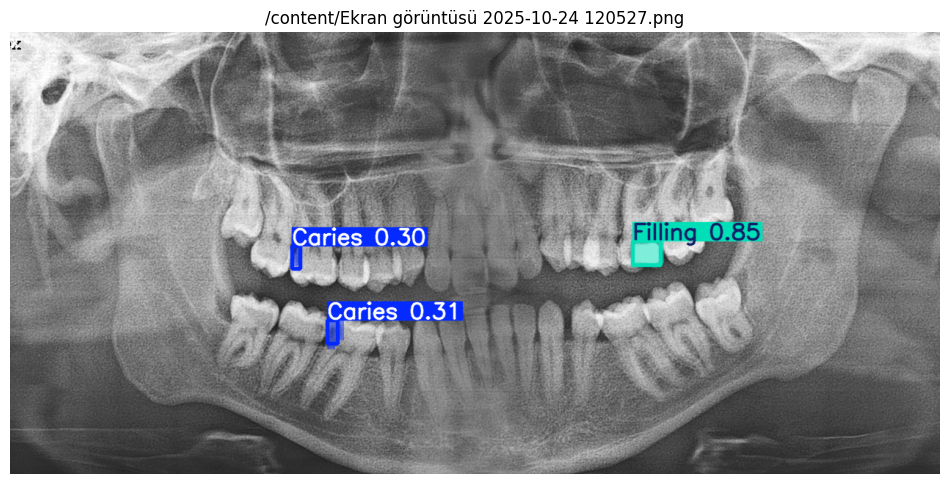

In [ ]:
from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt

# Egitilen modelin yolu
model_path = 'runs/segment/dis_modeli_v1/weights/best.pt'

# resmin yolu
resim_yolu = '/content/deneme.jpg'

# Modeli yükle
model = YOLO(model_path)

# Tahmin yap
results = model.predict("/content/Ekran görüntüsü 2025-10-24 120527.png", save=True, conf=0.25)

# Sonuç resmi
result_image = results[0].plot() # BGR formatında gelir

# Matplotlib icin renkleri düzeltip gösterelim
plt.figure(figsize=(12, 12))
plt.imshow(cv2.cvtColor(result_image, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.title(f"/content/Ekran görüntüsü 2025-10-24 120527.png")
plt.show()